In [1]:
using Pkg
Pkg.activate("./")
Pkg.develop(path="../../")
ENV["TAMBOSIM_PATH"] = realpath("../../")

  Activating project at `~/research/TAMBO-MC/notebooks/create_geometry`
   Resolving package versions...
  No Changes to `~/research/TAMBO-MC/notebooks/create_geometry/Project.toml`
  No Changes to `~/research/TAMBO-MC/notebooks/create_geometry/Manifest.toml`


"/Users/jlazar/research/TAMBO-MC"

In [2]:
using Revise
using Tambo
using Makie
using CairoMakie
using HDF5
# using StaticArrays
using LinearAlgebra
using Unitful
using StatsBase
include("../plotting_boilerplate.jl")

[ Info: Precompiling Tambo [d9a96183-4919-46da-8188-64ea4e10e0ed] (cache misses: include_dependency fsize change (6), wrong dep version loaded (4), dep missing source (10))
ERROR: LoadError: UndefVarError: `Object` not defined in `JSON`
Stacktrace:
 [1] getproperty(x::Module, f::Symbol)
   @ Base ./Base.jl:42
 [2] top-level scope
   @ ~/.julia/packages/JSON/0oqO1/ext/JSONArrowExt.jl:7
 [3] include
   @ ./Base.jl:557 [inlined]
 [4] include_package_for_output(pkg::Base.PkgId, input::String, depot_path::Vector{String}, dl_load_path::Vector{String}, load_path::Vector{String}, concrete_deps::Vector{Pair{Base.PkgId, UInt128}}, source::String)
   @ Base ./loading.jl:2881
 [5] top-level scope
   @ stdin:6
in expression starting at /Users/jlazar/.julia/packages/JSON/0oqO1/ext/JSONArrowExt.jl:1
in expression starting at stdin:6
┌ Error: Error during loading of extension JSONArrowExt of JSON, use `Base.retry_load_extensions()` to retry.
│   exception =
│    1-element ExceptionStack:
│    Failed t

Welcome to TAMBOSim version -0.1
Git commit hash: 57329d9c1fb0b69ca0fcad8bb0fbb06daa1911af
              /\    //\
             { `---'  }
             {  O   O  }
      _______{  \     /}________
    /  \     `._`---'_/     /  \
   /  |    ν_τ  `~.~`  ν_τ   |  \
  /   |        _.-'-.        |   \
 /    |     .'       `.     |    \
/     |    /           \    |     \ 
████████╗ █████╗ ███╗   ███╗██████╗  ██████╗ 
╚══██╔══╝██╔══██╗████╗ ████║██╔══██╗██╔═══██╗
   ██║   ███████║██╔████╔██║██████╔╝██║   ██║
   ██║   ██╔══██║██║╚██╔╝██║██╔══██╗██║   ██║
   ██║   ██║  ██║██║ ╚═╝ ██║██████╔╝╚██████╔╝
   ╚═╝   ╚═╝  ╚═╝╚═╝     ╚═╝╚═════╝  ╚═════╝ 
                                             


In [4]:
filename = "./triangulation.h5"
key = "colca_valley_30000"

earth = Tambo.Earth("$(filename):$(key)")
enu_coordinates = Tambo.CoordinateSystem(earth)

Tambo.CoordinateSystem{Float64, 𝐋}(Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}[1.8675398951159471e6 m, -5.844519015878025e6 m, -1.7156728164747716e6 m], [0.9525520923590841 0.3043756089806324 0.0; 0.08196656071668895 -0.25651667416993357 0.9630579830919183; 0.29313136008726215 -0.9173628968573262 -0.2692941165397538])

In [49]:
outline = Tuple{Float64, Float64}[]
for line in readlines("/Users/jlazar/Downloads/TAMBO_outline.csv")
    long, lat = deg2rad.(parse.(Float64, split(line, ", ")))
    push!(outline, (long, lat))
end
    
# This 
cog = [sum([x[1] for x in outline]), sum([x[2] for x in outline])] ./ length(outline)
phis = []
for (x,y) in outline
    push!(phis, atan(y-cog[2], x-cog[1]))
end
sorter = sortperm(phis)
outline = outline[sorter]

27-element Vector{Tuple{Float64, Float64}}:
 (-1.2616995870208432, -0.2726715154780103)
 (-1.2616953040042738, -0.2727202334080829)
 (-1.261682454954566, -0.2727617576410753)
 (-1.261620351214311, -0.27291886245169455)
 (-1.261588228590041, -0.27297577012921237)
 (-1.2615636012447675, -0.27305340395474104)
 (-1.2613954928444222, -0.2730529363644308)
 (-1.2613783607781448, -0.2730241173072047)
 (-1.261352662678729, -0.2729808887213656)
 (-1.261339813629021, -0.27293582297596447)
 (-1.2613312475958824, -0.27284745117414033)
 (-1.261339813629021, -0.27279691821895824)
 (-1.261352662678729, -0.2727553939859658)
 ⋮
 (-1.2613805022864297, -0.2725027679453473)
 (-1.2613269645793133, -0.272441571717647)
 (-1.26131625703789, -0.27237485294403435)
 (-1.261375148515718, -0.27227097319138915)
 (-1.2614297569769766, -0.2722708320842541)
 (-1.2614961437338008, -0.2722715625211884)
 (-1.261706011545697, -0.2722827459533416)
 (-1.2617723983025213, -0.27233218325312225)
 (-1.2618323605344919, -0.272384

In [50]:
coords = Tambo.Coordinate[]
for longlat in outline
    x, y, z = Tambo.longlat_to_cart(longlat...) .* earth.prem[end].radius
    c = Tambo.Coordinate(x, y, z, Tambo.ecefcoordinates)
    c = convert(enu_coordinates, c)
    push!(coords, c)
end

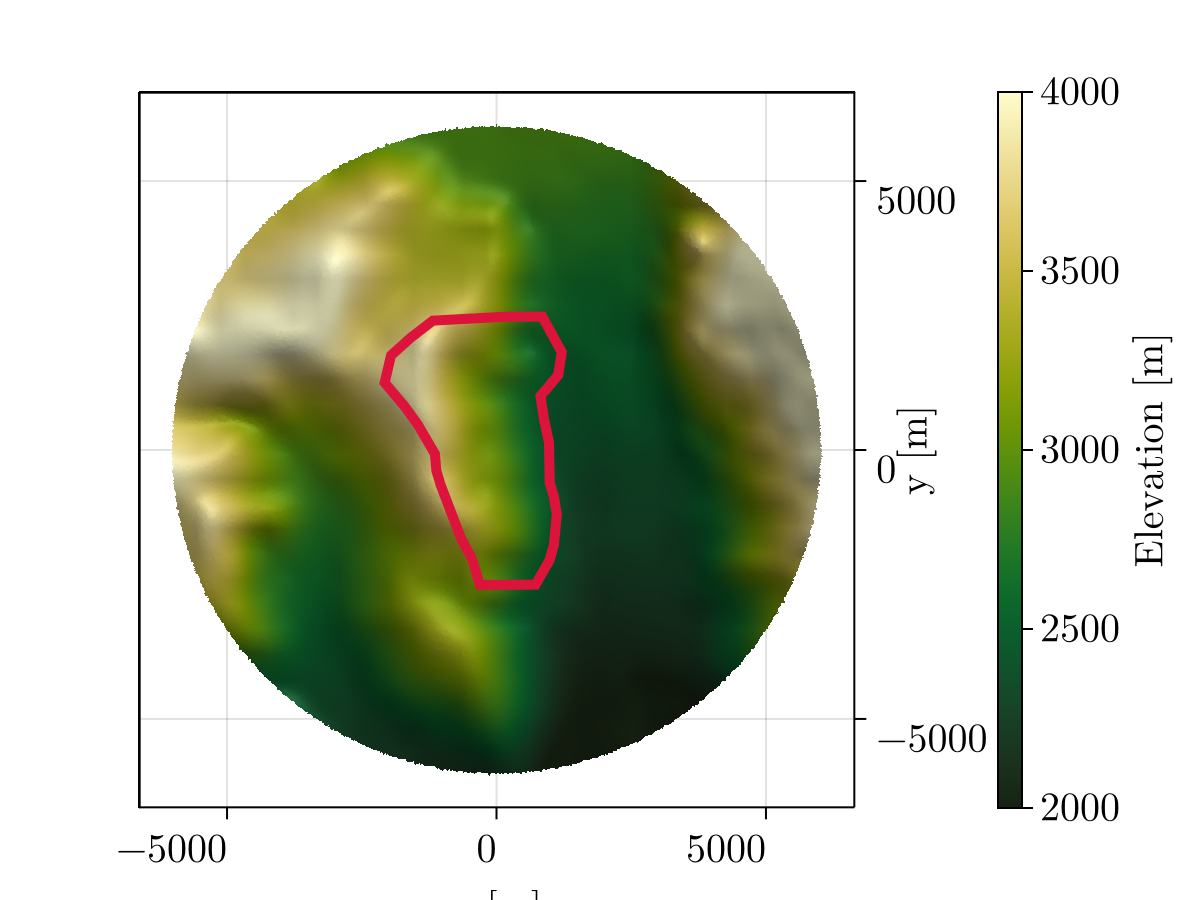

CairoMakie.Screen{IMAGE}


In [51]:
radius = 6 * u"km"
fig = Figure(
#     size=(1800, 450)
)

triangles = filter(triangle->norm(Tambo.centroid(triangle)[1:2]) < radius, earth.topography)
triangles = filter(triangle->Tambo.centroid(triangle)[3] > 0 * u"km", triangles)

vxs, faces = Tambo.triangles_to_mesh(triangles)

zaspect = 4500*Tambo.uparse("m") / (2 * radius)

ax = Axis3(
    fig[1, 1],
    azimuth=deg2rad(-90),
    elevation=deg2rad(90),
    aspect=(1, 1, zaspect),
    zgridvisible=false,
    zlabelvisible=false,
    zticklabelsvisible=false,
    zticksvisible=false,
    xlabel="x [m]",
    ylabel="y [m]",
)
zlims!(ax, 1000, 5500)

m = mesh!(
    ax,
    map(vx->Point3f(ustrip.(vx.point)), vxs),
    faces,
    color=[v.point.z.val for v in vxs],
    colormap=Reverse(:speed),
    colorrange=[2000, 4000]
)

lines!(
    ax,
    ustrip.(vcat([c[1] for c in coords], [coords[1][1]])),
    ustrip.(vcat([c[2] for c in coords], [coords[1][2]])),
    [2000.0 for _ in 1:length(outline)+1],
    linewidth=5,
    color=:crimson
)

# Axis 3: colorbar
colorbar = Colorbar(fig[1,2], m, label="Elevation [m]")

display(fig)

In [52]:
function is_in_outline(
    outline_points::Vector{Tuple{Float64,Float64}}, 
    test_point::Tuple{Float64,Float64}
)
    
    n = length(outline_points)
    inside = false

    j = n
    for i in 1:n
        xi, yi = outline_points[i]
        xj, yj = outline_points[j]
        px, py = test_point

        # Check if point is between the y-coordinates of the edge
        if ((yi > py) != (yj > py)) &&
           (px < (xj - xi) * (py - yi) / (yj - yi) + xi)
#                 inside = true
            inside = !inside
        end
        j = i
    end
    
    return inside
end

is_in_outline (generic function with 1 method)

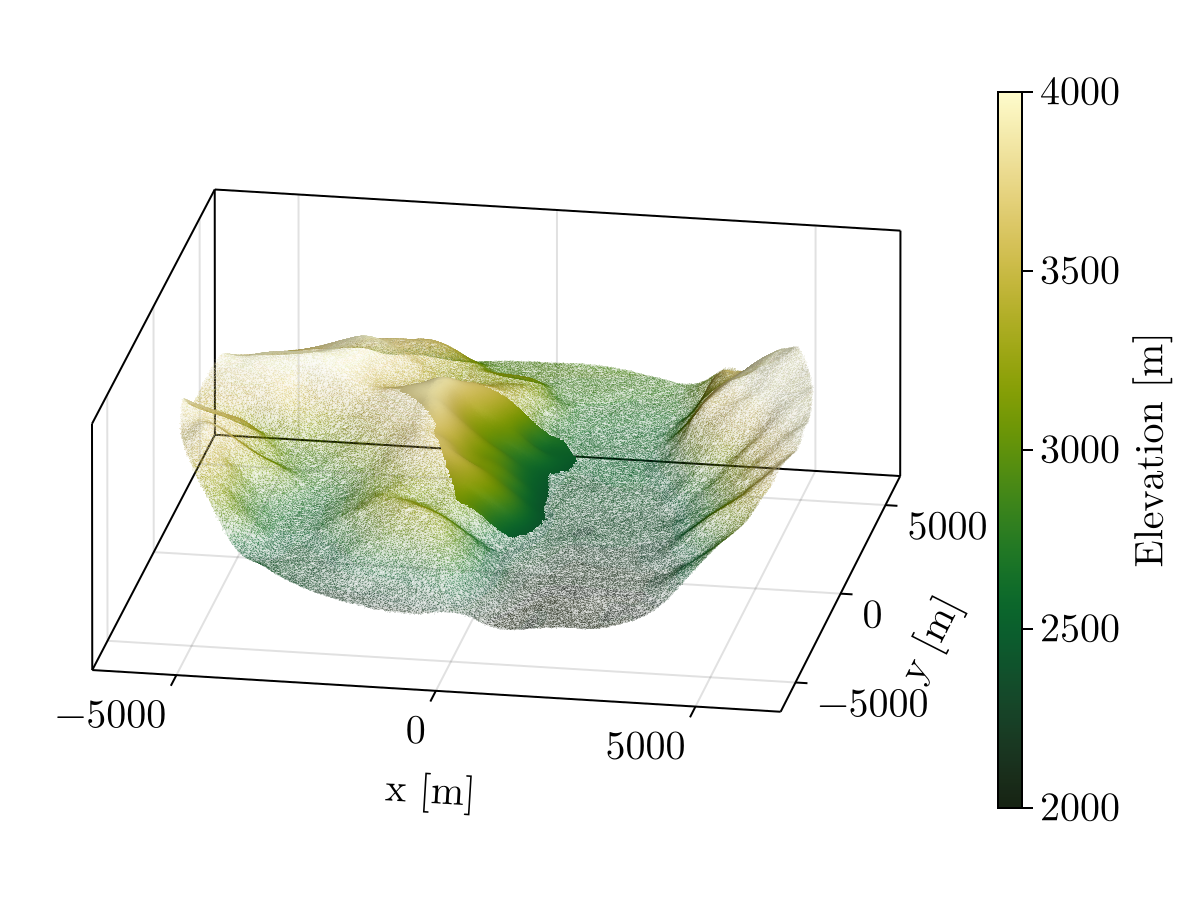

In [53]:
zaspect = 4500*Tambo.uparse("m") / (2 * radius)
    
fig = Figure()
ax = Axis3(
    fig[1, 1],
    azimuth=deg2rad(-80),
    elevation=deg2rad(20),
    aspect=(1, 1, zaspect),
    zgridvisible=false,
    zlabelvisible=false,
    zticklabelsvisible=false,
    zticksvisible=false,
    xlabel="x [m]",
    ylabel="y [m]",
#         margins = (50, 50, 50, 50)
)
zlims!(ax, 1000, 5500)
    
triangles = filter(triangle->norm(Tambo.centroid(triangle)[1:2]) < radius, earth.topography)
triangles = filter(triangle->Tambo.centroid(triangle)[3] > 0 * u"km", triangles)

vxs, faces = Tambo.triangles_to_mesh(triangles)

m = mesh!(
    ax,
    map(vx->Point3f(ustrip.(vx.point)), vxs),
    faces,
    color=[v.point.z.val for v in vxs],
    colormap=Reverse(:speed),
    colorrange=[2000, 4000],
    alpha=0.1
)

longlats = Tuple{Float64, Float64}[]
for triangle in earth.topography
    c = Tambo.centroid(triangle)
    long, lat = Tambo.cart_to_longlat(c)
    push!(longlats, (long, lat))
end

triangles = earth.topography[is_in_outline.(Ref(outline), longlats)]

vxs, faces = Tambo.triangles_to_mesh(triangles)

m = mesh!(
    ax,
    map(vx->Point3f(ustrip.(vx.point)), vxs),
    faces,
    color=[v.point.z.val for v in vxs],
    colormap=Reverse(:speed),
    colorrange=[2000, 4000]
) 

# Axis 3: colorbar
colorbar = Colorbar(fig[1,2], m, label="Elevation [m]")
    
fig

In [54]:
idxs = findall(is_in_outline.(Ref(outline), longlats))
h5open(filename, "r+") do file
    group = file[key]
    group["detector1"] = idxs
end

20815-element Vector{Int64}:
     44
     45
     46
     47
    120
    121
    122
    123
    124
    243
    244
    245
    246
      ⋮
 600090
 600200
 600212
 600228
 600230
 600256
 600257
 600260
 600261
 600458
 600485
 600528